In [4]:
# Cell 1: Importing Libraries

import pandas as pd
import numpy as np
import time

import rdkit
from rdkit import Chem
from rdkit.Chem import Draw, AllChem
from rdkit.Chem import PandasTools

from mordred import Calculator, descriptors

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score

import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

# from lazypredict.Supervised import LazyRegressor

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from collections import Counter

from sklearn.inspection import permutation_importance
import shap

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

In [5]:
# Cell 2: Reading the Dataset

# Read the dataset from a CSV file into a pandas DataFrame
data = pd.read_csv('dataset.csv')

# Display the first five rows of the dataset
# data.head()


# Create an empty list to store the generated RDKit molecule objects
mol_list = []

# Loop through each SMILES string in the 'SMILES' column
# enumerate() so an invalid molecule can be traced to its dataset row
for index, smile in enumerate(data['SMILES']):

    # Convert the SMILES string into an RDKit molecule object
    mol = Chem.MolFromSmiles(smile)

    # stop execution with a clear message if the SMILES is invalid
    # Without this check, Chem.AddHs(None) would cause an unclear RDKit error
    if mol is None:
        raise ValueError(
            f"Invalid SMILES at row {index}: {smile}"
        )

    # Add explicit hydrogen atoms to the molecule
    mol = Chem.AddHs(mol)

    # Generate a 3D conformation for the molecule
    # set randomSeed for reproducible conformer generation
    embedding_status = AllChem.EmbedMolecule(
        mol,
        randomSeed=42
    )

    # verify that conformer generation was successful
    # RDKit returns -1 when embedding fails
    if embedding_status == -1:
        raise RuntimeError(
            f"3D conformer generation failed at row {index}: {smile}"
        )

    # Add the processed molecule object to the list
    mol_list.append(mol)


# Convert the molecule list into a DataFrame with a column named 'Mol'
# and concatenate it with the original dataset column-wise
data = pd.concat(
    [data, pd.DataFrame(mol_list, columns=['Mol'])],
    axis=1
)

# Display the first five rows of the updated dataset
# data.head()

In [6]:
# Cell 3: Calculating Molecular Descriptors

# Create a descriptor calculator that includes all available molecular descriptors
# Setting ignore_3D=False allows the calculation of both 2D and 3D descriptors
calc = Calculator(descriptors, ignore_3D=False)

# Calculate all molecular descriptors for each molecule in the 'Mol' column
# The results are returned as a pandas DataFrame
all_desc = calc.pandas(data['Mol'])

# Display the first five rows of the calculated descriptors
# all_desc.head()

# Print the number of rows and columns in the descriptor DataFrame
# print(all_desc.shape)

100%|██████████| 1144/1144 [00:38<00:00, 30.01it/s]


In [7]:
# Cell 4: Combining Original Data with Descriptors

# Select the compound identifier, SMILES representation, and measured solubility columns
df_index = data[['Compound ID', 'SMILES', 'measured log(solubility:mol/L)']]

# Combine the selected original columns with the calculated molecular descriptors
df = pd.concat([df_index, all_desc], axis=1)

# Display the first five rows of the combined DataFrame
# df.head()

In [21]:
# Cell 5: Data Preprocessing and Feature Selection

# Select all columns from the fourth column onward
# The first three columns are excluded from the new DataFrame
data = df.iloc[:, 3:]

# Display the first five rows
# display(data.head())

# Count and display the total number of missing (NaN/null) values
# in all rows and columns of the DataFrame
print(f'Total Number of Missing Values: {data.isnull().sum().sum()}')

# Create an empty list to store the names of numerical columns
column_num = []

# Create an empty list to store the names of Boolean columns
column_bool = []

# Loop through every column in the DataFrame
for column in data.columns:

    # Get the data type of the current column
    column_type = data[column].dtype

    # Check whether the column contains object data,
    # such as strings, text, Mordred errors, or missing descriptor objects
    if column_type == "object":

        # Skip the object column without adding it to either list
        pass

    # Check whether the column contains Boolean values
    elif column_type == "bool":

        # Add the Boolean column's name to the Boolean list
        column_bool.append(column)

    # Treat all other column types as numerical
    else:

        # Add the numerical column's name to the numerical list
        column_num.append(column)

# Use len() to count the Boolean columns and print the result
print(f'Total Number of Boolean Columns: {len(column_bool)}')

# corrected the output label from "Boolean Columns" to
# "Numerical Columns" because this prints len(column_num)
print(f'Total Number of Numerical Columns: {len(column_num)}')

# Display the names of all Boolean columns stored in the column_bool list
display(f'Boolean Column Names: {column_bool}')

# Display all unique values found in the 'Lipinski' column
print(f"All unique values found in Lipinski Column: {data['Lipinski'].unique()}")

# Display all unique values found in the 'GhoseFilter' column
print(
    f"All unique values found in GhoseFilter Column: "
    f"{data['GhoseFilter'].unique()}"
)

# Decide train/test row membership now, before any
# feature-selection statistics (constant columns, correlation) are computed.
# Those statistics are fit on the TRAINING rows only in the next cells, so
# information from the test set never influences which features are kept.
# random_state=45 must match the train_test_split used later for modeling.
train_idx, test_idx = train_test_split(
    data.index,
    test_size=0.20,
    random_state=45
)

Total Number of Missing Values: 0
Total Number of Boolean Columns: 2
Total Number of Numerical Columns: 1284


"Boolean Column Names: ['Lipinski', 'GhoseFilter']"

All unique values found in Lipinski Column: [ True False]
All unique values found in GhoseFilter Column: [False  True]


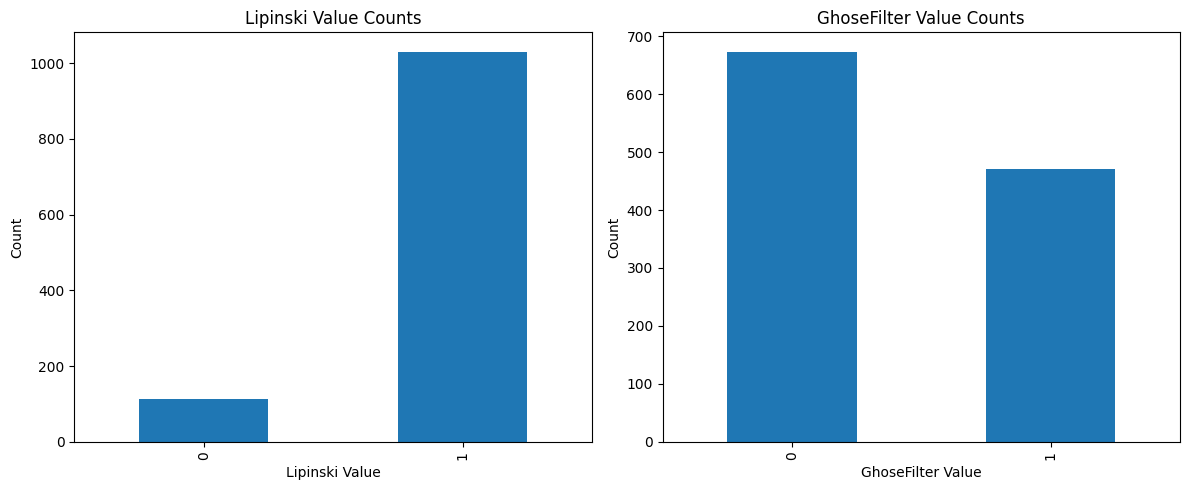

In [9]:
# Cell 6: Visualizing Lipinski and GhoseFilter Value Counts

# Convert the values in the 'Lipinski' column to integers
Lipinski = data['Lipinski'].astype(int)

# Convert the values in the 'GhoseFilter' column to integers
gf = data['GhoseFilter'].astype(int)

# Create one figure containing two subplots arranged in one row and two columns
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot the frequency of each Lipinski value on the first subplot
Lipinski.value_counts().sort_index().plot(
    kind='bar',
    ax=axes[0]
)

# Set the title and axis labels for the Lipinski subplot
axes[0].set_title('Lipinski Value Counts')
axes[0].set_xlabel('Lipinski Value')
axes[0].set_ylabel('Count')

# Plot the frequency of each GhoseFilter value on the second subplot
gf.value_counts().sort_index().plot(
    kind='bar',
    ax=axes[1]
)

# Set the title and axis labels for the GhoseFilter subplot
axes[1].set_title('GhoseFilter Value Counts')
axes[1].set_xlabel('GhoseFilter Value')
axes[1].set_ylabel('Count')

# Adjust the spacing between the two subplots
plt.tight_layout()

# Display the figure containing both subplots
plt.show()

In [10]:
# Cell 7: Removing Constant Descriptors

def remove_constant_values(data):
    # Return columns that contain only one unique value
    return [
        column
        for column in data.columns
        if data[column].nunique() == 1
    ]


# Keep only the numerical and Boolean descriptor columns
data = data[column_num + column_bool]

# Print the shape before removing constant descriptors
print(data.shape)

# Identify constant columns using the TRAINING rows only.
# This prevents information from the test set from influencing
# which descriptors are selected.
drop_col = remove_constant_values(data.loc[train_idx])

# Keep only columns that are not constant in the training data
new_df_columns = [
    column
    for column in data.columns
    if column not in drop_col
]

# Create a new DataFrame containing the remaining descriptors
# for all training and test rows
new_df = data[new_df_columns].copy()

# Print the total number of constant columns identified
print(
    f'Total number of constant columns that were identified: '
    f'{len(drop_col)}'
)


(1144, 1286)
Total number of constant columns that were identified: 154


In [11]:
# Cell 8: Correlation Filtering

# Calculate correlations and identify highly correlated columns
# Correlation filtering reduces redundant predictors.

def correlation(dataset, threshold):
    # Store the names of columns that should be removed
    col_corr = set()

    # Calculate the correlation matrix for numeric columns
    corr_matrix = dataset.corr(numeric_only=True)

    # Loop through the lower triangle of the correlation matrix
    for i in range(len(corr_matrix.columns)):
        for j in range(i):

            # Check whether the absolute correlation exceeds the threshold
            if abs(corr_matrix.iloc[i, j]) > threshold:

                # Mark the later column for removal
                colname = corr_matrix.columns[i]
                col_corr.add(colname)

    return col_corr


# convert these Boolean descriptor columns to integers
# before correlation filtering rather than adding them back afterward.
# This ensures they are evaluated consistently with the other predictors.
if 'Lipinski' in new_df.columns:
    new_df['Lipinski'] = new_df['Lipinski'].astype(int)

if 'GhoseFilter' in new_df.columns:
    new_df['GhoseFilter'] = new_df['GhoseFilter'].astype(int)


# Compute correlations using the TRAINING rows only.
# This prevents the test set from influencing which features are retained.
corr_features = correlation(
    new_df.loc[train_idx],
    0.80
)

print('Number of features to drop:', len(corr_features))

# Remove the highly correlated features from all rows
new_df.drop(
    columns=list(corr_features),
    inplace=True
)

print(new_df.shape)

# Display the first five rows
new_df.head()


Number of features to drop: 852
(1144, 280)


,ABC,nBase,SpMAD_A,VR1_A,nAromAtom,nSpiro,nBridgehead,nHetero,nN,nO,...,JGI3,JGI4,JGI5,JGI6,JGI7,JGI8,JGI9,JGI10,Lipinski,GhoseFilter
0,4.012290,0,0.969771,11.637367,0,0,0,4,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0
1,3.464102,0,0.800000,8.000000,0,0,0,3,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0
2,3.932653,0,1.000000,11.530010,0,0,0,4,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0
3,3.047207,0,1.045250,8.629874,0,0,0,3,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0
4,5.808525,0,0.901388,17.881697,0,0,0,6,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0


In [12]:
# Cell 9: Saving the Preprocessed Dataset

# Combine the first three columns from df with all columns from new_df
# axis=1 joins the DataFrames horizontally, placing their columns side by side
df_final = pd.concat(
    [df.iloc[:, :3], new_df],
    axis=1
)

# Display the first five rows of the final DataFrame
# display(df_final.head())

# Save the final preprocessed DataFrame as a CSV file
# use index=False explicitly so pandas does not save
# the DataFrame index as an additional CSV column
df_final.to_csv(
    'dataset_preprocessed.csv',
    index=False
)


count    1144.000000
mean       -3.057997
std         2.096502
min       -11.600000
25%        -4.332250
50%        -2.870500
75%        -1.600000
max         1.580000
Name: measured log(solubility:mol/L), dtype: float64

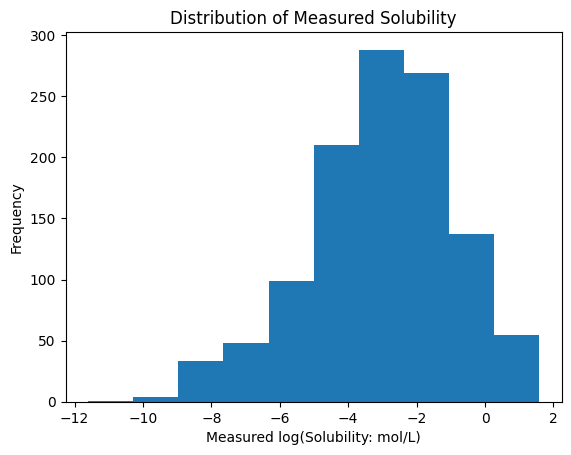

In [13]:
# Cell 10: Descriptive Statistics and Histogram

# Calculate and display descriptive statistics for the measured solubility column
# The output includes count, mean, standard deviation, minimum,
# quartiles, and maximum values
display(
    df_final['measured log(solubility:mol/L)'].describe()
)

# Create a histogram showing the distribution of measured solubility values
plt.hist(
    df_final['measured log(solubility:mol/L)']
)

# add a descriptive title and axis labels
plt.title('Distribution of Measured Solubility')
plt.xlabel('Measured log(Solubility: mol/L)')
plt.ylabel('Frequency')

# explicitly display the completed plot
plt.show()


In [14]:
# Cell 11: Correlation Analysis

# create a separate DataFrame for correlation analysis instead of
# overwriting df_final. This preserves Compound ID and SMILES for later use.
df_corr = df_final.iloc[:, 2:].copy()

# Calculate the pairwise correlation between all numerical columns
# numeric_only=True makes the operation explicit and version-safe
corr = df_corr.corr(numeric_only=True)

# Display the complete correlation matrix in a formatted table
display(corr)


,measured log(solubility:mol/L),ABC,nBase,SpMAD_A,VR1_A,nAromAtom,nSpiro,nBridgehead,nHetero,nN,...,JGI3,JGI4,JGI5,JGI6,JGI7,JGI8,JGI9,JGI10,Lipinski,GhoseFilter
measured log(solubility:mol/L),1.000000,-0.587292,0.009436,-0.400888,-0.042746,-0.489810,0.009736,-0.095359,-0.179433,0.066841,...,-0.144504,-0.166640,-0.242768,-0.407580,-0.352430,-0.381077,-0.296588,-0.284985,0.536947,-0.319041
ABC,-0.587292,1.000000,0.026669,0.518070,0.269720,0.485949,0.047461,0.103426,0.622045,0.256624,...,0.371893,0.252384,0.438656,0.603095,0.630818,0.649665,0.604904,0.568986,-0.403142,0.580382
nBase,0.009436,0.026669,1.000000,-0.022689,-0.003478,0.011546,-0.006465,-0.008918,0.053709,0.150348,...,0.032084,-0.005389,0.056558,0.008089,0.127106,0.010402,0.018965,-0.002792,0.025631,0.039911
SpMAD_A,-0.400888,0.518070,-0.022689,1.000000,0.034976,0.614815,0.023255,0.063530,0.072628,0.132353,...,0.158292,0.406323,0.292834,0.363907,0.247982,0.284155,0.210123,0.173100,-0.200843,0.307161
VR1_A,-0.042746,0.269720,-0.003478,0.034976,1.000000,-0.031358,-0.003541,-0.004722,0.159333,-0.024607,...,0.025229,0.017358,0.016255,0.053924,0.047015,0.063713,0.073997,0.094727,-0.136917,-0.029163
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
JGI8,-0.381077,0.649665,0.010402,0.284155,0.063713,0.276180,0.016945,-0.035987,0.423663,0.152328,...,0.148927,0.083582,0.259373,0.541474,0.616922,1.000000,0.552580,0.429913,-0.210515,0.521385
JGI9,-0.296588,0.604904,0.018965,0.210123,0.073997,0.189807,0.008003,-0.050169,0.353518,0.071457,...,0.135920,0.046194,0.178560,0.378284,0.475748,0.552580,1.000000,0.553025,-0.193187,0.394118
JGI10,-0.284985,0.568986,-0.002792,0.173100,0.094727,0.142253,-0.012563,-0.037981,0.300058,0.040651,...,0.107922,0.029615,0.136373,0.266449,0.344662,0.429913,0.553025,1.000000,-0.156746,0.318947
Lipinski,0.536947,-0.403142,0.025631,-0.200843,-0.136917,-0.317888,0.027918,-0.102014,-0.193421,0.174111,...,-0.071523,-0.043597,-0.062052,-0.221331,-0.170497,-0.210515,-0.193187,-0.156746,1.000000,0.082633


,correlation_coef
PEOE_VSA6,0.705928
RNCG,0.627965
ABC,0.587292
Mor20m,0.549087


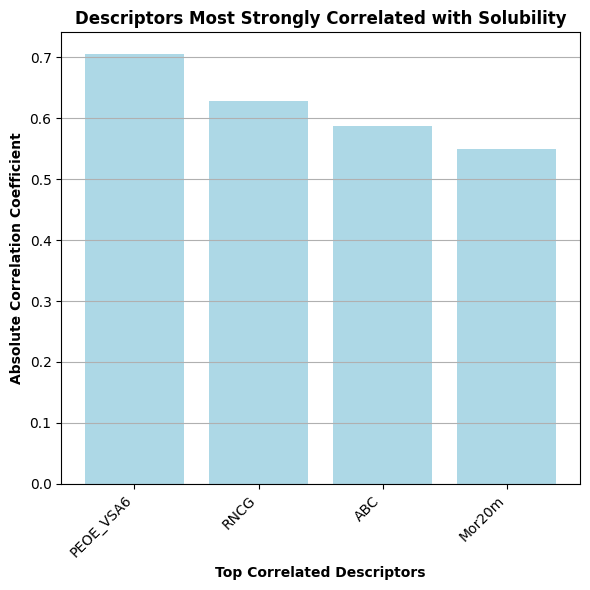

Index(['PEOE_VSA6', 'RNCG', 'ABC', 'Mor20m'], dtype='object')

In [15]:
# Cell 12: Selecting Features Most Strongly Correlated with Solubility

# Select the absolute correlations with the target solubility column
corr_sorted = abs(
    corr[["measured log(solubility:mol/L)"]]
).sort_values(
    by="measured log(solubility:mol/L)",
    ascending=False
)

# Skip the first row because it is the target column's correlation with itself (= 1)
# Keep the next four most strongly correlated features
corr_sorted = corr_sorted.iloc[1:5, :]

# Rename the column for clarity
corr_sorted.rename(
    columns={
        "measured log(solubility:mol/L)": "correlation_coef"
    },
    inplace=True
)

# Display the four features most strongly correlated with solubility
display(corr_sorted)

# Create a new figure with figure number 1 and a size of 6 × 6 inches
fig = plt.figure(1, figsize=(6, 6))

# Add one subplot to the figure
# 111 means one row, one column, and the first subplot position
ax1 = fig.add_subplot(111)

# Create a light-blue bar chart using descriptor names as the x-axis values
# and their absolute correlation coefficients as the bar heights
plt.bar(
    x=corr_sorted.index,
    height=corr_sorted['correlation_coef'],
    color='lightblue'
)

# Add horizontal grid lines to make the bar heights easier to compare
# limit the grid to the y-axis so it does not clutter descriptor labels
ax1.grid(axis='y')

# add a descriptive title
ax1.set_title(
    'Descriptors Most Strongly Correlated with Solubility',
    weight='bold'
)

# Add a bold label to the x-axis
ax1.set_xlabel('Top Correlated Descriptors', weight='bold')

# Add a bold label to the y-axis
ax1.set_ylabel('Absolute Correlation Coefficient', weight='bold')

# rotate descriptor names to prevent overlapping labels
plt.xticks(rotation=45, ha='right')

# adjust spacing and explicitly display the completed figure
plt.tight_layout()
plt.show()

# Return the index labels of corr_sorted
# These labels represent the names of the most strongly correlated descriptors
display(corr_sorted.index)

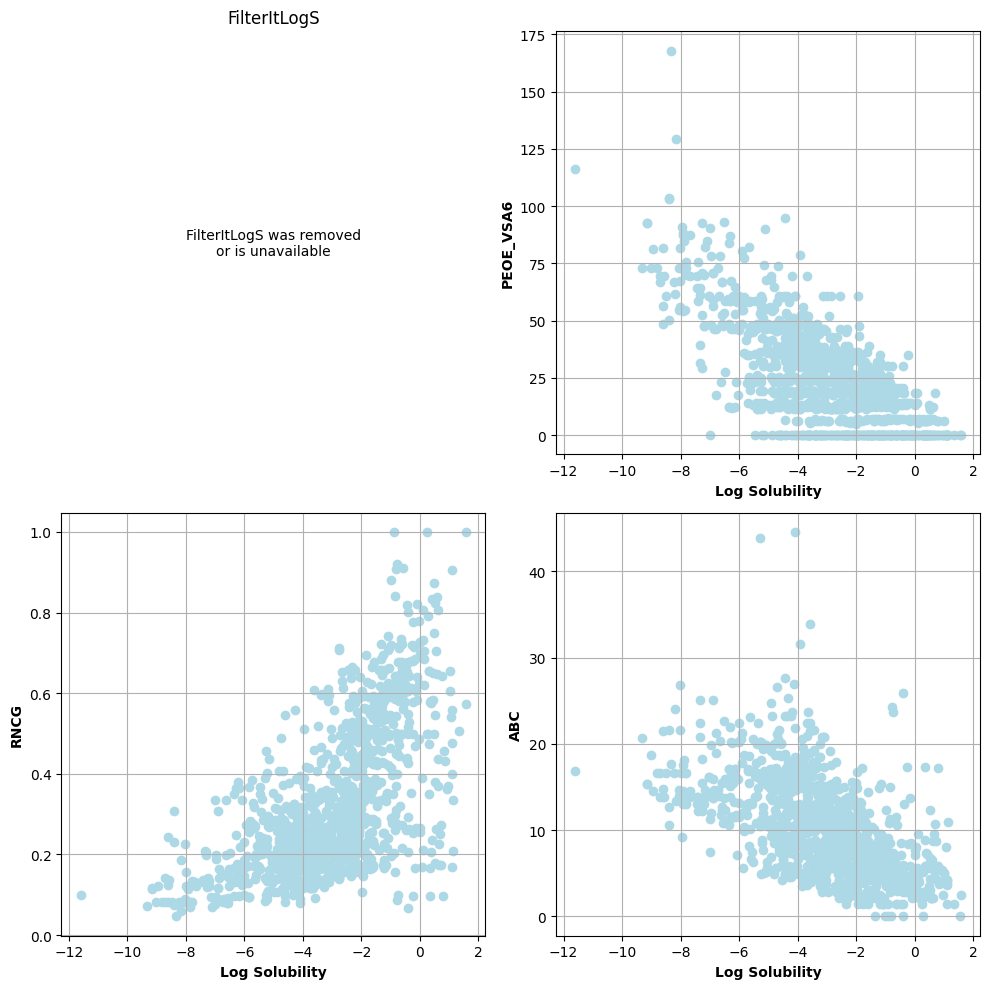

In [16]:
# Cell 13: Scatter Plots of Solubility vs. Molecular Descriptors

# Create a new figure containing four scatter plots arranged in a 2 × 2 grid
# Each plot compares measured log solubility with one molecular descriptor
fig = plt.figure(4, figsize=(10, 10))


# Add the first subplot in the top-left position
ax = fig.add_subplot(221)

# plot FilterItLogS only if it survived the preprocessing steps
if 'FilterItLogS' in df_final.columns:

    ax.scatter(
        x=df_final['measured log(solubility:mol/L)'],
        y=df_final['FilterItLogS'],
        color='lightblue'
    )

    ax.set_xlabel('Log Solubility', weight='bold')
    ax.set_ylabel('FilterItLogS', weight='bold')
    ax.grid()

else:
    # clearly indicate why this subplot cannot be created
    ax.text(
        0.5,
        0.5,
        'FilterItLogS was removed\nor is unavailable',
        ha='center',
        va='center',
        transform=ax.transAxes
    )
    ax.set_title('FilterItLogS')
    ax.set_axis_off()


# Add the second subplot in the top-right position
ax = fig.add_subplot(222)

# Plot measured log solubility against PEOE_VSA6
ax.scatter(
    x=df_final['measured log(solubility:mol/L)'],
    y=df_final['PEOE_VSA6'],
    color='lightblue'
)

# Add axis labels and grid lines
ax.set_xlabel('Log Solubility', weight='bold')
ax.set_ylabel('PEOE_VSA6', weight='bold')
ax.grid()


# Add the third subplot in the bottom-left position
ax = fig.add_subplot(223)

# Plot measured log solubility against RNCG
ax.scatter(
    x=df_final['measured log(solubility:mol/L)'],
    y=df_final['RNCG'],
    color='lightblue'
)

# Add axis labels and grid lines
ax.set_xlabel('Log Solubility', weight='bold')
ax.set_ylabel('RNCG', weight='bold')
ax.grid()


# Add the fourth subplot in the bottom-right position
ax = fig.add_subplot(224)

# Plot measured log solubility against ABC
ax.scatter(
    x=df_final['measured log(solubility:mol/L)'],
    y=df_final['ABC'],
    color='lightblue'
)

# Add axis labels and grid lines
ax.set_xlabel('Log Solubility', weight='bold')
ax.set_ylabel('ABC', weight='bold')
ax.grid()


# Adjust the spacing between the four subplots
plt.tight_layout()

# explicitly display the complete figure
plt.show()

In [17]:
# Cell 14: Model Training and Evaluation

# Read the preprocessed dataset from the CSV file
df_final = pd.read_csv('dataset_preprocessed.csv')

# Select the measured log solubility column as the target variable
y = df_final['measured log(solubility:mol/L)']

# Select molecular descriptors as input features
# The first three columns are Compound ID, SMILES, and the target
X_raw = df_final.iloc[:, 3:]

# Split before scaling to prevent test-set statistics from leaking
# into the training features.
# random_state=45 matches the earlier train_idx/test_idx split.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.20,
    random_state=45
)

# Fit the scaler using the training data only
scaler = StandardScaler()

X_train = pd.DataFrame(
    scaler.fit_transform(X_train_raw),
    columns=X_raw.columns,
    index=X_train_raw.index
)

# Apply the same fitted scaler to the held-out test data
X_test = pd.DataFrame(
    scaler.transform(X_test_raw),
    columns=X_raw.columns,
    index=X_test_raw.index
)

# Keep a separately scaled full-dataset version only for unsupervised
# visualization such as t-SNE. Do not use it for supervised evaluation.
scaled_DF = pd.DataFrame(
    StandardScaler().fit_transform(X_raw),
    columns=X_raw.columns,
    index=X_raw.index
)

# Create a Linear Regression model
lr = LinearRegression()

# Train the Linear Regression model using the training data
lr.fit(X_train, y_train)

# Print the R² score on the training set
print(
    f'The Linear Regression r2 score for train set is: '
    f'{lr.score(X_train, y_train)}'
)

# Print the R² score on the testing set
print(
    f'The Linear Regression r2 score for test set is: '
    f'{lr.score(X_test, y_test)}'
)

# set random_state for reproducible Random Forest results
rf = RandomForestRegressor(
    random_state=45
)

# Train the Random Forest Regression model using the training data
rf.fit(X_train, y_train)

# Print the R² score on the training set
print(
    f'The Random Forest Regressor r2 score for train set is: '
    f'{rf.score(X_train, y_train)}'
)

# Print the R² score on the testing set
print(
    f'The Random Forest Regressor r2 score for test set is: '
    f'{rf.score(X_test, y_test)}'
)

# Calculate predictions on the held-out test set
rf_test_pred = rf.predict(X_test)

# MAE and RMSE report error magnitude in log(mol/L) units
print(
    f'Random Forest test MAE: '
    f'{mean_absolute_error(y_test, rf_test_pred):.3f}'
)

print(
    f'Random Forest test RMSE: '
    f'{root_mean_squared_error(y_test, rf_test_pred):.3f}'
)


The Linear Regression r2 score for train set is: 0.9542085935287832
The Linear Regression r2 score for test set is: 0.7540822263017735
The Random Forest Regressor r2 score for train set is: 0.9819327931656379
The Random Forest Regressor r2 score for test set is: 0.8628926635124206
Random Forest test MAE: 0.553
Random Forest test RMSE: 0.770


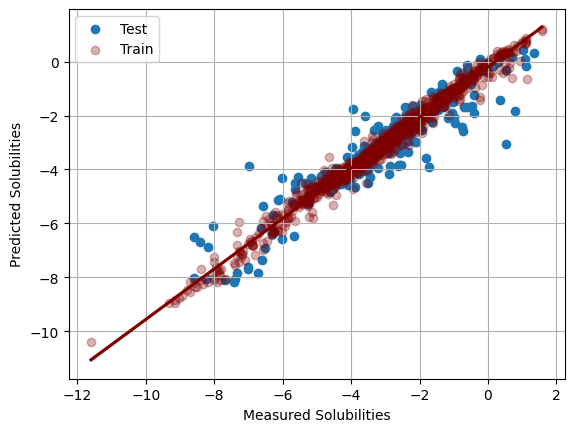

In [18]:
# Cell 15: Visualizing Random Forest Predictions

# Generate predictions once so the same values are reused consistently
# avoids calling rf.predict() multiple times
rf_train_pred = rf.predict(X_train)
rf_test_pred = rf.predict(X_test)

# Create a scatter plot comparing the measured testing values
# with the Random Forest predictions for the testing set
plt.scatter(
    y_test,
    rf_test_pred,
    label='Test'
)

# Create a regression plot comparing the measured training values
# with the Random Forest predictions for the training set
# alpha=0.3 makes the training points partially transparent
sns.regplot(
    x=y_train,
    y=rf_train_pred,
    color='maroon',
    scatter_kws={'alpha': 0.3},
    label='Train'
)

# Label the x-axis with the measured solubility values
plt.xlabel('Measured Solubilities')

# the y-axis contains predicted values, not actual values
plt.ylabel('Predicted Solubilities')

# Add grid lines to make the values easier to compare
plt.grid()

# Display the legend identifying the training and testing data
plt.legend()

# explicitly display the completed plot
plt.show()


In [19]:
# Cell 16: Cross-Validation

# Evaluate the Random Forest model using 5-fold cross-validation
# The training data is divided into five parts, called folds
val = cross_val_score(
    rf,
    X_train,
    y_train,
    scoring="r2",  # Use the R² score to measure model performance
    cv=5           # Train and validate the model five times using different folds
)

# Print the R² validation score obtained from each fold
print(f'The r2 score for each fold: {val}')

# Print the average R² score across all five validation folds
print(f'Average cross-validation r2 score: {val.mean()}')


The r2 score for each fold: [0.88541341 0.85495562 0.86586607 0.87694054 0.86039496]
Average cross-validation r2 score: 0.8687141191612788


In [20]:
# Cell 17: Comparing Multiple Regression Models with LazyRegressor

# Create a separate training/validation split for comparing regression models
# keep X_test and y_test untouched for final model evaluation
X_lazy_train_raw, X_lazy_val_raw, y_lazy_train, y_lazy_val = train_test_split(
    X_train_raw,
    y_train,
    test_size=0.20,
    random_state=45
)

# fit a separate scaler using only the LazyRegressor training subset
# This prevents validation-set statistics from leaking into model comparison
lazy_scaler = StandardScaler()

X_lazy_train = pd.DataFrame(
    lazy_scaler.fit_transform(X_lazy_train_raw),
    columns=X_train_raw.columns,
    index=X_lazy_train_raw.index
)

X_lazy_val = pd.DataFrame(
    lazy_scaler.transform(X_lazy_val_raw),
    columns=X_train_raw.columns,
    index=X_lazy_val_raw.index
)

# Initialize LazyRegressor to automatically compare multiple regression models
reg = LazyRegressor(
    verbose=0,              # Disable detailed progress messages
    ignore_warnings=False,  # Show warnings generated while fitting models
    custom_metric=None      # Use LazyRegressor's default evaluation metrics
)

# compare models using the training and validation subsets,
# not the held-out final test set
models, predictions = reg.fit(
    X_lazy_train,
    X_lazy_val,
    y_lazy_train,
    y_lazy_val
)

# Display the prediction-results object returned by LazyRegressor
display(predictions)

# Display the model comparison table
display(models)

NameError: name 'LazyRegressor' is not defined

In [ ]:
# Cell 18: Principal Component Analysis (PCA)

# Fit PCA using only the already-scaled TRAINING features
# from the previous modeling cell.
# The fitted PCA is then applied to the test features.
pca = PCA(n_components=8)

pc_train = pca.fit_transform(X_train)
pc_test = pca.transform(X_test)

# add descriptive principal-component column names
# while preserving the original row indices
pc_columns = [f'PC{i}' for i in range(1, 9)]

pc_train_df = pd.DataFrame(
    pc_train,
    columns=pc_columns,
    index=X_train.index
)

pc_test_df = pd.DataFrame(
    pc_test,
    columns=pc_columns,
    index=X_test.index
)

# Display the first five rows of the training principal-component DataFrame
display(pc_train_df.head())

# Print the proportion of the training-set variance
# explained by each principal component
print(pca.explained_variance_ratio_)

# Print the total variance explained by all eight components
print(
    f'Total explained variance: '
    f'{pca.explained_variance_ratio_.sum():.4f}'
)

# pc_train_df / pc_test_df and y_train / y_test already correspond
# to the same leakage-free split used in the previous modeling section.

# Add a constant column to represent the intercept term in the OLS model
x = sm.add_constant(pc_train_df)

# Create and fit an Ordinary Least Squares regression model
results = sm.OLS(y_train, x).fit()

# Print the complete statistical summary of the fitted OLS model
print(results.summary())


# use a distinct variable name so the earlier Linear Regression
# model trained on the original descriptors is not overwritten
lr_pca = LinearRegression()

# Train Linear Regression using the principal components
lr_pca.fit(pc_train_df, y_train)

print(
    f'The PCA Linear Regression r2 score for train set is: '
    f'{lr_pca.score(pc_train_df, y_train)}'
)

print(
    f'The PCA Linear Regression r2 score for test set is: '
    f'{lr_pca.score(pc_test_df, y_test)}'
)


# use a distinct variable name and set random_state
# for reproducible PCA-based Random Forest results
rf_pca = RandomForestRegressor(
    random_state=45
)

# Train Random Forest using the principal components
rf_pca.fit(pc_train_df, y_train)

print(
    f'The PCA Random Forest Regressor r2 score for train set is: '
    f'{rf_pca.score(pc_train_df, y_train)}'
)

print(
    f'The PCA Random Forest Regressor r2 score for test set is: '
    f'{rf_pca.score(pc_test_df, y_test)}'
)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
867,1.455946,2.574906,-1.451172,2.828931,5.847995,-2.711880,-0.850443,-1.420837
627,-9.212438,-9.146858,2.723581,-7.428849,-5.686828,3.789715,-8.854213,-4.002602
195,-5.599779,-1.391804,-2.259328,0.730714,1.348337,-0.301116,1.464358,0.004210
1122,-6.571757,1.722398,-2.025266,3.833315,0.814823,-1.353083,-0.427644,0.053832
847,-0.882060,2.709947,-0.302231,1.927791,1.598480,1.571356,2.621621,-0.109519


[0.11062893 0.08488891 0.05677858 0.04558404 0.04096094 0.02956741
 0.02780055 0.02555702]
Total explained variance: 0.4218
                                  OLS Regression Results                                  
Dep. Variable:     measured log(solubility:mol/L)   R-squared:                       0.686
Model:                                        OLS   Adj. R-squared:                  0.683
Method:                             Least Squares   F-statistic:                     246.9
Date:                            Sun, 02 Aug 2026   Prob (F-statistic):          1.20e-221
Time:                                    17:47:07   Log-Likelihood:                -1447.7
No. Observations:                             915   AIC:                             2913.
Df Residuals:                                 906   BIC:                             2957.
Df Model:                                       8                                         
Covariance Type:                        nonrobust        

The median solubility is: -2.8705
Counter({0: 586, 1: 558})


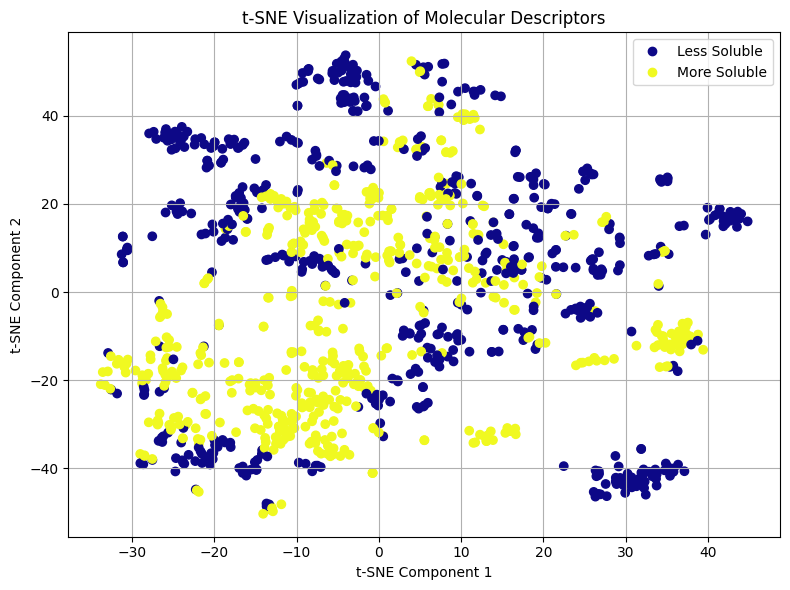

In [ ]:
# Cell 19: t-SNE Visualization of Molecular Descriptors

# Create a t-SNE model that reduces the dataset to two dimensions
# random_state makes the stochastic t-SNE result reproducible
tsne = TSNE(
    n_components=2,
    random_state=45
)

# Fit t-SNE to the scaled full dataset and transform it
# This is used only for exploratory visualization
ts = tsne.fit_transform(scaled_DF)

# Convert the transformed t-SNE values into a DataFrame
# preserve the original row index and use descriptive column names
tsne_df = pd.DataFrame(
    data=ts,
    columns=['TSNE1', 'TSNE2'],
    index=scaled_DF.index
)

# Display the first five rows
# display(tsne_df.head())

# CHANGED: this calculation uses median(), not mean()
print(f'The median solubility is: {y.median()}')

# Classify each solubility value:
# 1 means the value is greater than -2.8
# 0 means the value is -2.8 or lower
sol_cls = [
    int(solubility > -2.8)
    for solubility in y
]

# Count how many samples belong to each class
print(Counter(sol_cls))

# Create a new figure with a width of 8 inches and a height of 6 inches
plt.figure(figsize=(8, 6))

# Create a scatter plot using the first and second t-SNE components
# Each point represents one compound
# The point color is determined by its solubility class
scatter = plt.scatter(
    tsne_df['TSNE1'],
    tsne_df['TSNE2'],
    c=sol_cls,
    cmap='plasma'
)

# class 0 is less soluble and class 1 is more soluble.
# legend_elements() returns the class values in ascending order: 0, then 1.
plt.legend(
    handles=scatter.legend_elements()[0],
    labels=['Less Soluble', 'More Soluble'],
    loc='upper right'
)

# Add grid lines to make the positions easier to observe
plt.grid()

# Label the horizontal and vertical axes
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')

# add a descriptive title
plt.title('t-SNE Visualization of Molecular Descriptors')

# explicitly display the completed plot
plt.tight_layout()
plt.show()

The Linear Regression r2 score for train set is: 0.9542085935287832
The Linear Regression r2 score for test set is: 0.7540822263017735
The Random Forest Regressor r2 score for train set is: 0.9819327931656379
The Random Forest Regressor r2 score for test set is: 0.8628926635124206
The six most important descriptors are:


,Features,Importance
207,PEOE_VSA6,0.295173
3,VR1_A,0.126430
0,ABC,0.116338
278,Lipinski,0.086254
95,RNCG,0.067463
16,ATS0Z,0.035359
94,FPSA3,0.019975
208,PEOE_VSA7,0.017261


C:\Users\musta\AppData\Local\Temp\ipykernel_27008\2808156451.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


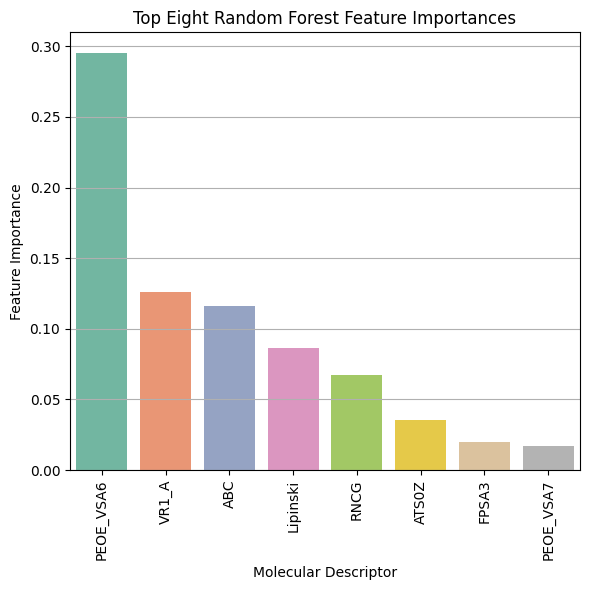

In [ ]:
# Cell 20: Feature Importance Analysis 

# Reuse the leakage-free X_train/X_test/y_train/y_test
# from the earlier modeling section.

# use a distinct variable name so the earlier Linear Regression
# model is not overwritten
lr_fi = LinearRegression()

# Train the Linear Regression model
lr_fi.fit(X_train, y_train)

print(
    f'The Linear Regression r2 score for train set is: '
    f'{lr_fi.score(X_train, y_train)}'
)

print(
    f'The Linear Regression r2 score for test set is: '
    f'{lr_fi.score(X_test, y_test)}'
)


# use a distinct variable name and set random_state
# so the feature-importance results are reproducible
rf_fi = RandomForestRegressor(
    random_state=45
)

# Train the Random Forest model
rf_fi.fit(X_train, y_train)

print(
    f'The Random Forest Regressor r2 score for train set is: '
    f'{rf_fi.score(X_train, y_train)}'
)

print(
    f'The Random Forest Regressor r2 score for test set is: '
    f'{rf_fi.score(X_test, y_test)}'
)


# Extract the feature-importance scores learned by the Random Forest model
importance = rf_fi.feature_importances_

# Create a dictionary containing the feature names and importance scores
# X_train.columns guarantees that the names match the fitted model inputs
dicts = {
    'Features': list(X_train.columns),
    'Importance': importance
}

# Convert the feature names and importance scores into a DataFrame
DF_imp = pd.DataFrame(dicts)

# Sort the features from highest to lowest importance
DF_imp = DF_imp.sort_values(
    'Importance',
    ascending=False
)

# Save the complete feature-importance table to an Excel file
# use index=False explicitly
DF_imp.to_excel(
    'feature_importance.xlsx',
    index=False
)

# Select the six most important descriptors for visualization
top_desc_fi = DF_imp.head(8)

print('The six most important descriptors are:')
display(top_desc_fi)

# Create a figure with a size of 6 × 6 inches
plt.figure(figsize=(6, 6))

# Create a bar plot showing the six most important molecular descriptors
sns.barplot(
    data=top_desc_fi,
    x='Features',
    y='Importance',
    palette='Set2'
)

plt.xlabel('Molecular Descriptor')
plt.ylabel('Feature Importance')
plt.title('Top Eight Random Forest Feature Importances')

plt.xticks(rotation=90)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


,Features,Importance
207,PEOE_VSA6,0.124795
278,Lipinski,0.086030
3,VR1_A,0.084992
0,ABC,0.069820
95,RNCG,0.037349


The eight most important features are:


,Features,Importance
207,PEOE_VSA6,0.124795
278,Lipinski,0.086030
3,VR1_A,0.084992
0,ABC,0.069820
95,RNCG,0.037349
16,ATS0Z,0.028165
149,SIC0,0.013607
143,ETA_dEpsilon_D,0.010608


C:\Users\musta\AppData\Local\Temp\ipykernel_27008\2165937969.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


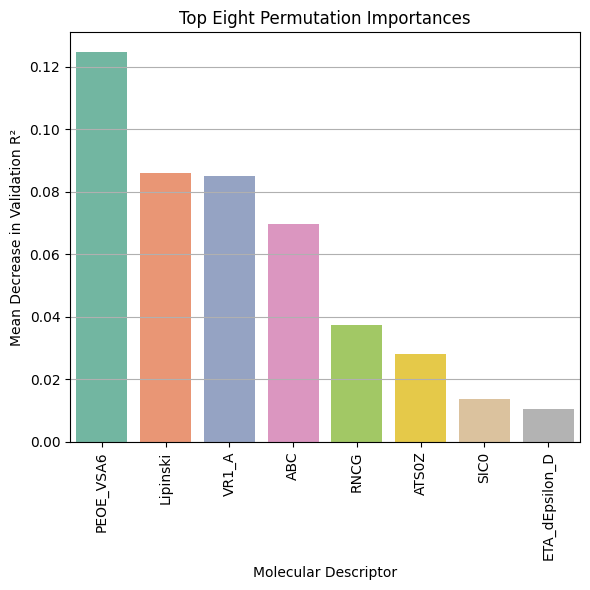

In [ ]:
# Cell 21: Permutation Importance Analysis

# create a training/validation split from the existing training set.
# The final X_test and y_test remain untouched for final model evaluation.
X_pi_train, X_pi_val, y_pi_train, y_pi_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=45
)

# train a separate reproducible Random Forest for
# permutation-importance analysis
rf_pi = RandomForestRegressor(
    random_state=45
)

rf_pi.fit(X_pi_train, y_pi_train)

# Calculate permutation importance using the validation subset
# Each feature is shuffled to measure how much validation performance decreases
result = permutation_importance(
    rf_pi,
    X_pi_val,
    y_pi_val,
    scoring='r2',
    n_repeats=10,
    random_state=42
)

# Create a dictionary containing feature names and their
# average permutation-importance scores
dicts = {
    'Features': list(X_pi_val.columns),
    'Importance': result.importances_mean
}

# Convert feature names and permutation-importance scores into a DataFrame
DF_pi = pd.DataFrame(dicts)

# Sort the actual permutation-importance results
DF_pi = DF_pi.sort_values(
    'Importance',
    ascending=False
)

# Save the sorted permutation-importance results to an Excel file
# use index=False explicitly
DF_pi.to_excel(
    'feature_importance_permutation.xlsx',
    index=False
)

# Display the five features with the highest importance scores
display(DF_pi.head())

# Select the six most important features for visualization
top_desc_pi = DF_pi.head(8)

print('The eight most important features are:')
display(top_desc_pi)

# Create a figure for the eight most important features
plt.figure(figsize=(6, 6))

# Create a bar plot showing the eight most important features
sns.barplot(
    data=top_desc_pi,
    x='Features',
    y='Importance',
    palette='Set2'
)

plt.xlabel('Molecular Descriptor')
plt.ylabel('Mean Decrease in Validation R²')
plt.title('Top Eight Permutation Importances')

plt.xticks(rotation=90)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


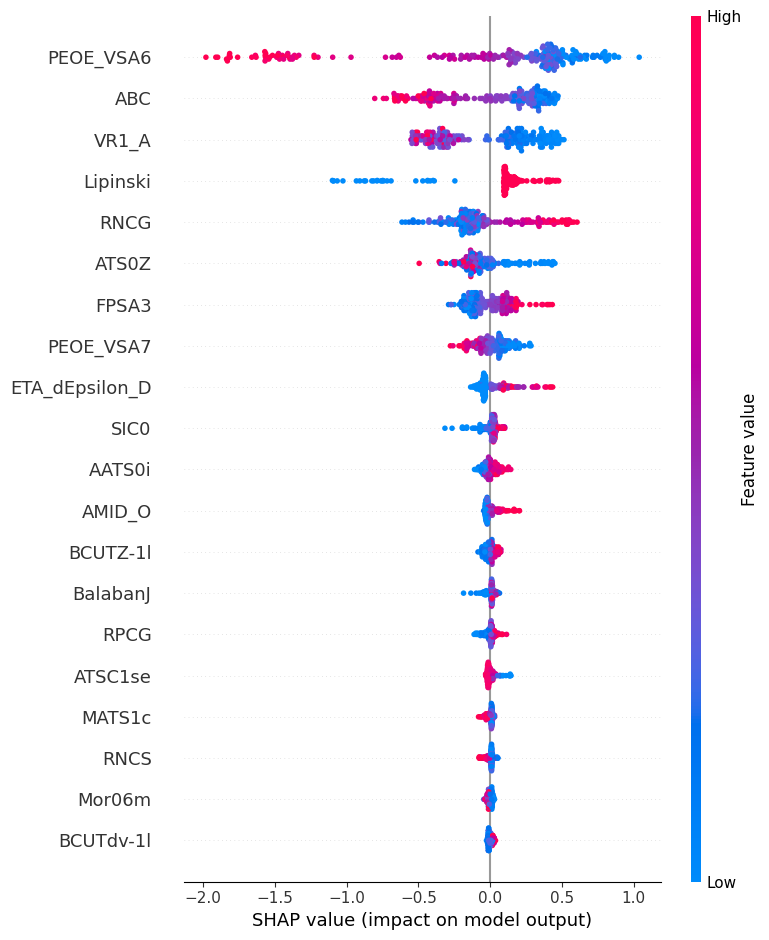

In [ ]:
# Cell 22: SHAP Analysis

# Create a SHAP TreeExplainer for the Random Forest model
# trained on the original molecular descriptors
# CHANGED: use rf_fi instead of the ambiguous variable rf
explainer = shap.TreeExplainer(rf_fi)

# Calculate SHAP values for every feature and sample in the testing dataset
# Positive SHAP values increase the predicted solubility,
# while negative SHAP values decrease the predicted solubility
shap_values = explainer.shap_values(X_test)

# Display a SHAP summary plot showing the overall influence of each feature
# Features are ordered from most influential to least influential
# Each point represents one sample from the testing dataset
shap.summary_plot(
    shap_values,
    X_test
)

In [ ]:
# Cell 23: Saving the Reduced Eight-Feature Dataset

# Select the names of the eight most important features
# store the feature names once so the same ordered list is reused
top_8_features = DF_imp.head(8)['Features'].tolist()

# Display the selected feature names
print('The eight most important features are:')
display(top_8_features)

# Create a new DataFrame containing only the eight most important features
df_final_8 = df_final[top_8_features].copy()

# Display the first five rows of the reduced eight-feature DataFrame
display(df_final_8.head())

# Save the reduced eight-feature DataFrame to a CSV file
# corrected the comment and use index=False explicitly
df_final_8.to_csv(
    'dataset_8_des.csv',
    index=False

)

The eight most important features are:


['PEOE_VSA6',
 'VR1_A',
 'ABC',
 'Lipinski',
 'RNCG',
 'ATS0Z',
 'FPSA3',
 'PEOE_VSA7']

,PEOE_VSA6,VR1_A,ABC,Lipinski,RNCG,ATS0Z,FPSA3,PEOE_VSA7
0,34.80282,11.637367,4.012290,1,0.330754,1230.0,0.007215,0.000000
1,34.80282,8.000000,3.464102,1,0.311690,942.0,0.006069,6.923737
2,0.00000,11.530010,3.932653,1,0.250000,1230.0,0.008611,0.000000
3,0.00000,8.629874,3.047207,1,0.372917,942.0,0.013714,0.000000
4,23.20188,17.881697,5.808525,1,0.277752,1182.0,0.000000,11.600940


In [ ]:
# Cell 24: Modeling with the Reduced Eight-Feature Dataset

# Select the measured log solubility column as the target variable
y = df_final['measured log(solubility:mol/L)']

# Split the reduced eight-feature dataset before scaling
# random_state=45 keeps the same train/test row membership as earlier sections
X_train_raw8, X_test_raw8, y_train8, y_test8 = train_test_split(
    df_final_8,
    y,
    test_size=0.20,
    random_state=45
)

# Fit the scaler using only the eight-feature training data
scaler_8 = StandardScaler()

# use distinct variable names for the eight-feature datasets
# so the earlier full-feature X_train and X_test are not overwritten
X_train8 = pd.DataFrame(
    scaler_8.fit_transform(X_train_raw8),
    columns=df_final_8.columns,
    index=X_train_raw8.index
)

X_test8 = pd.DataFrame(
    scaler_8.transform(X_test_raw8),
    columns=df_final_8.columns,
    index=X_test_raw8.index
)

# use a distinct model name and set random_state
# for reproducible eight-feature Random Forest results
rf_8 = RandomForestRegressor(
    random_state=45
)

rf_8.fit(X_train8, y_train8)

print(
    f'The eight-feature Random Forest Regressor r2 score for train set is: '
    f'{rf_8.score(X_train8, y_train8)}'
)

print(
    f'The eight-feature Random Forest Regressor r2 score for test set is: '
    f'{rf_8.score(X_test8, y_test8)}'
)

# use a distinct model name and set random_state
# for reproducible eight-feature Extra Trees results
et_8 = ExtraTreesRegressor(
    random_state=45
)

et_8.fit(X_train8, y_train8)

print(
    f'The eight-feature Extra Trees Regressor r2 score for train set is: '
    f'{et_8.score(X_train8, y_train8)}'
)

print(
    f'The eight-feature Extra Trees Regressor r2 score for test set is: '
    f'{et_8.score(X_test8, y_test8)}'
)


The eight-feature Random Forest Regressor r2 score for train set is: 0.9788228641305451
The eight-feature Random Forest Regressor r2 score for test set is: 0.8322855517476218
The eight-feature Extra Trees Regressor r2 score for train set is: 0.9993155464328399
The eight-feature Extra Trees Regressor r2 score for test set is: 0.83573836998753


In [ ]:
# Cell 25: Hyperparameter Tuning for Random Forest with Grid Search

# Create a Random Forest regression model for the eight-feature dataset
rf_grid_base = RandomForestRegressor(
    n_estimators=100,
    bootstrap=True,
    max_depth=None,
    max_features=1.0,
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=45,
    n_jobs=-1
)

# Create a grid search to test different Random Forest
# hyperparameter combinations
clf_rf = GridSearchCV(
    estimator=rf_grid_base,

    param_grid={
        'n_estimators': [400, 600, 700, 800, 900],
        'bootstrap': [True, False],

        # CHANGED: test different limits on tree depth
        'max_depth': [None, 10, 20, 30, 40, 45],

        'max_features': ['log2', 'sqrt'],
        'min_samples_leaf': [2, 4],
        'min_samples_split': [5, 10]
    },

    cv=3,
    verbose=0,
    scoring='r2',
    n_jobs=-1
)

# Record the time before grid-search training
start = time.time()

# Train using the eight-feature training set
clf_rf.fit(X_train8, y_train8)

# Record the time after training
end = time.time()

print(
    "Execution time of the program is",
    end - start,
    "seconds"
)

# Display the best hyperparameters
display(clf_rf.best_params_)

# Display the best mean cross-validation score
print(
    f'Best mean cross-validation r2 score: '
    f'{clf_rf.best_score_:.4f}'
)


Execution time of the program is 408.14966440200806 seconds


{'bootstrap': False,
 'max_depth': None,
 'max_features': 'sqrt',
 'min_samples_leaf': 2,
 'min_samples_split': 5,
 'n_estimators': 700}

Best mean cross-validation r2 score: 0.8503


In [ ]:
# Cell 26: Final Model Evaluation with the Tuned Random Forest

# Reuse the tuned Random Forest model obtained from the previous grid-search cell
rf_final = clf_rf.best_estimator_

# Train/test scores using the synchronized eight-feature datasets
print(
    f'The final Random Forest Regressor r2 score for train set is: '
    f'{rf_final.score(X_train8, y_train8)}'
)

print(
    f'The final Random Forest Regressor r2 score for test set is: '
    f'{rf_final.score(X_test8, y_test8)}'
)


The final Random Forest Regressor r2 score for train set is: 0.9843686038673094
The final Random Forest Regressor r2 score for test set is: 0.8248178060574702


In [ ]:
# Cell 27: Hyperparameter Tuning for Extra Trees with Grid Search

# Create an Extra Trees regression model for the eight-feature dataset
# use a distinct model name and set random_state for reproducibility
et_grid_base = ExtraTreesRegressor(
    bootstrap=True,
    max_depth=None,
    max_features=1.0,
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=100,
    random_state=45,
    n_jobs=-1
)

# Perform a grid search to find the best Extra Trees hyperparameters
clf_et = GridSearchCV(
    estimator=et_grid_base,

    param_grid={
        'n_estimators': [200, 400, 600, 800, 1000],
        'bootstrap': [True, False],
        'max_depth': [10, 30, 60, 85, 100, None],
        'max_features': ['log2', 'sqrt'],
        'min_samples_leaf': [2, 4],
        'min_samples_split': [5, 10]
    },

    cv=3,
    verbose=0,
    scoring='r2',
    n_jobs=-1
)

# Record the time immediately before training starts
start = time.time()

# tune the model using the synchronized eight-feature training data
clf_et.fit(X_train8, y_train8)

# Record the time immediately after training finishes
end = time.time()

# Calculate and display the total training time
print(
    "Execution time of the program is",
    end - start,
    "seconds"
)

# Display the best hyperparameter combination
display(clf_et.best_params_)

# display the best mean cross-validation R²
print(
    f'Best mean cross-validation r2 score: '
    f'{clf_et.best_score_:.4f}'
)

# store the already-fitted best estimator for later evaluation
et_final = clf_et.best_estimator_

Execution time of the program is 256.6628198623657 seconds


{'bootstrap': False,
 'max_depth': 30,
 'max_features': 'log2',
 'min_samples_leaf': 2,
 'min_samples_split': 5,
 'n_estimators': 400}

Best mean cross-validation r2 score: 0.8463


In [ ]:
# Cell 28: Final Model Evaluation with the Tuned Extra Trees

# Reuse the best Extra Trees model selected and fitted by GridSearchCV
et_final = clf_et.best_estimator_

# Evaluate the final Extra Trees model using the synchronized
# eight-feature training and testing datasets
print(
    f'The final Extra Trees Regressor r2 score for train set is: '
    f'{et_final.score(X_train8, y_train8)}'
)

print(
    f'The final Extra Trees Regressor r2 score for test set is: '
    f'{et_final.score(X_test8, y_test8)}'
)

The final Extra Trees Regressor r2 score for train set is: 0.9459775891806216
The final Extra Trees Regressor r2 score for test set is: 0.8070424585649189


In [ ]:
# Cell 29: Hyperparameter Tuning for Random Forest with Randomized Search

# Perform a randomized search to find strong Random Forest hyperparameters
clf_rf_rs = RandomizedSearchCV(
    # use the dedicated eight-feature Random Forest base estimator
    estimator=rf_grid_base,

    param_distributions={
        'bootstrap': [True, False],
        'max_depth': [10, 30, 60, 85, 100, None],
        'max_features': ['log2', 'sqrt'],
        'min_samples_leaf': [2, 4],
        'min_samples_split': [5, 10],
        'n_estimators': [200, 400, 600, 800, 1000]
    },

    n_iter=10,
    scoring='r2',
    cv=3,

    # make the randomly sampled combinations reproducible
    random_state=45,

    # use available processor cores
    n_jobs=-1,

    verbose=0
)

# Record the time immediately before training starts
start = time.time()

# train using the synchronized eight-feature training data
clf_rf_rs.fit(X_train8, y_train8)

# Record the time immediately after training finishes
end = time.time()

# Calculate and display the total training time in seconds
print(
    "Execution time of the program is",
    end - start,
    "seconds"
)

# Display the best randomly selected hyperparameter combination
display(clf_rf_rs.best_params_)

# display the best mean cross-validation R²
print(
    f'Best mean cross-validation r2 score: '
    f'{clf_rf_rs.best_score_:.4f}'
)

# Store the already fitted best randomized-search estimator
rf_rs_final = clf_rf_rs.best_estimator_


Execution time of the program is 9.754956007003784 seconds


{'n_estimators': 1000,
 'min_samples_split': 5,
 'min_samples_leaf': 2,
 'max_features': 'log2',
 'max_depth': 10,
 'bootstrap': True}

Best mean cross-validation r2 score: 0.8484


In [ ]:
# Cell 30: Final Model Evaluation with the Randomized-Search Random Forest

# Reuse the best Random Forest model selected and fitted
# by RandomizedSearchCV in the previous cell
rf_rs_final = clf_rf_rs.best_estimator_

# Evaluate the model using the synchronized eight-feature datasets
print(
    f'The randomized-search Random Forest r2 score for train set is: '
    f'{rf_rs_final.score(X_train8, y_train8)}'
)

print(
    f'The randomized-search Random Forest r2 score for test set is: '
    f'{rf_rs_final.score(X_test8, y_test8)}'
)

The randomized-search Random Forest r2 score for train set is: 0.9501974216164475
The randomized-search Random Forest r2 score for test set is: 0.8086977388360829


In [ ]:
# Cell 31: Final Model Evaluation Using the Synchronized Eight-Feature Dataset

# Read the dataset containing the selected eight descriptors
df_final_8 = pd.read_csv('dataset_8_des.csv')

# read the target from the synchronized preprocessed dataset
# rather than from the original dataset.csv
dataset_preprocessed = pd.read_csv('dataset_preprocessed.csv')

# Display the first five rows of the eight-descriptor dataset
display(df_final_8.head())

# Select the measured log solubility column as the target variable
y_final = dataset_preprocessed['measured log(solubility:mol/L)']

# confirm that the predictors and target contain the same rows
if len(df_final_8) != len(y_final):
    raise ValueError(
        'dataset_8_des.csv and dataset_preprocessed.csv contain '
        'different numbers of rows.'
    )

# Split before fitting the scaler
X_train_raw_final, X_test_raw_final, y_train_final, y_test_final = (
    train_test_split(
        df_final_8,
        y_final,
        test_size=0.20,
        random_state=45
    )
)

# Fit the scaler on the training data only
scaler_final = StandardScaler()

X_train_final = pd.DataFrame(
    scaler_final.fit_transform(X_train_raw_final),
    columns=df_final_8.columns,
    index=X_train_raw_final.index
)

X_test_final = pd.DataFrame(
    scaler_final.transform(X_test_raw_final),
    columns=df_final_8.columns,
    index=X_test_raw_final.index
)


# build the final Random Forest directly from the
# hyperparameters returned by RandomizedSearchCV
rf_final = RandomForestRegressor(
    **clf_rf_rs.best_params_,
    random_state=45,
    n_jobs=-1
)

rf_final.fit(X_train_final, y_train_final)

print(
    f'The final Random Forest Regressor r2 score for train set is: '
    f'{rf_final.score(X_train_final, y_train_final)}'
)

print(
    f'The final Random Forest Regressor r2 score for test set is: '
    f'{rf_final.score(X_test_final, y_test_final)}'
)


# build the final Extra Trees model directly from the
# hyperparameters returned by GridSearchCV
et_final = ExtraTreesRegressor(
    **clf_et.best_params_,
    random_state=45,
    n_jobs=-1
)

et_final.fit(X_train_final, y_train_final)

print(
    f'The final Extra Trees Regressor r2 score for train set is: '
    f'{et_final.score(X_train_final, y_train_final)}'
)

print(
    f'The final Extra Trees Regressor r2 score for test set is: '
    f'{et_final.score(X_test_final, y_test_final)}'
)


# Calculate predictions on the held-out test set
rf_pred_final = rf_final.predict(X_test_final)
et_pred_final = et_final.predict(X_test_final)

# Report error magnitudes in log(mol/L)
print(
    f'Random Forest test MAE: '
    f'{mean_absolute_error(y_test_final, rf_pred_final):.3f} | '
    f'RMSE: {root_mean_squared_error(y_test_final, rf_pred_final):.3f}'
)

print(
    f'Extra Trees test MAE: '
    f'{mean_absolute_error(y_test_final, et_pred_final):.3f} | '
    f'RMSE: {root_mean_squared_error(y_test_final, et_pred_final):.3f}'
)

,PEOE_VSA6,VR1_A,ABC,Lipinski,RNCG,ATS0Z,FPSA3,PEOE_VSA7
0,34.80282,11.637367,4.012290,1,0.330754,1230.0,0.007215,0.000000
1,34.80282,8.000000,3.464102,1,0.311690,942.0,0.006069,6.923737
2,0.00000,11.530010,3.932653,1,0.250000,1230.0,0.008611,0.000000
3,0.00000,8.629874,3.047207,1,0.372917,942.0,0.013714,0.000000
4,23.20188,17.881697,5.808525,1,0.277752,1182.0,0.000000,11.600940


The final Random Forest Regressor r2 score for train set is: 0.9501974216164475
The final Random Forest Regressor r2 score for test set is: 0.8086977388360829
The final Extra Trees Regressor r2 score for train set is: 0.9459775891806216
The final Extra Trees Regressor r2 score for test set is: 0.8070424585649189
Random Forest test MAE: 0.636 | RMSE: 0.909
Extra Trees test MAE: 0.645 | RMSE: 0.913


In [ ]:
# Cell 32: Display the Final Feature Names

final_feature_names = X_train_final.columns.tolist()
print(final_feature_names)

['PEOE_VSA6', 'VR1_A', 'ABC', 'Lipinski', 'RNCG', 'ATS0Z', 'FPSA3', 'PEOE_VSA7']


In [ ]:
# Cell 33: Predicting Solubility from a SMILES String

# Define a function that predicts solubility from a SMILES string
def predict_sol(smile):

    # Convert the SMILES string into an RDKit molecule object
    mol = Chem.MolFromSmiles(smile)

    # Validate the input SMILES
    if mol is None:
        raise ValueError(f"Could not parse SMILES string: {smile!r}")

    # Keep a hydrogen-free molecule for clearer 2D visualization
    mol_for_image = Chem.Mol(mol)

    # Add explicit hydrogen atoms before descriptor calculation
    mol = Chem.AddHs(mol)

    # Generate a reproducible three-dimensional molecular conformation
    embed_status = AllChem.EmbedMolecule(
        mol,
        randomSeed=45
    )

    # RDKit returns -1 when conformer generation fails
    if embed_status != 0:
        raise ValueError(
            f"Could not generate a 3D conformer for: {smile!r}"
        )

    # Store the molecule in a one-row DataFrame
    df_mol = pd.DataFrame(
        {'mol': [mol]}
    )

    # Create the same Mordred descriptor calculator used during training
    calc = Calculator(
        descriptors,
        ignore_3D=False
    )

    # Calculate descriptors for the input molecule
    desc = calc.pandas(df_mol['mol'])

    # obtain the exact eight descriptors and their order
    # from the final training dataset
    required_features = X_train_final.columns.tolist()

    # Confirm that all required descriptors were calculated
    missing_features = [
        feature
        for feature in required_features
        if feature not in desc.columns
    ]

    if missing_features:
        raise ValueError(
            f"Required descriptors were not calculated: "
            f"{missing_features}"
        )

    # Select descriptors in exactly the same order used for training
    desc_8 = desc[required_features].copy()

    # Convert Mordred outputs to numeric values
    # Invalid Mordred values become NaN
    desc_8 = desc_8.apply(
        pd.to_numeric,
        errors='coerce'
    )

    # Stop if any required descriptor could not be calculated
    if desc_8.isna().any().any():
        invalid_features = desc_8.columns[
            desc_8.isna().any()
        ].tolist()

        raise ValueError(
            f"Could not calculate valid numeric values for: "
            f"{invalid_features}"
        )

    # Standardize using the scaler fitted on the final training set
    X_new = pd.DataFrame(
        scaler_final.transform(desc_8),
        columns=required_features,
        index=desc_8.index
    )

    # Predict solubility using the final trained models
    predict_rf = rf_final.predict(X_new)
    predict_et = et_final.predict(X_new)

    # Generate and display a two-dimensional molecular image
    img = Draw.MolToImage(mol_for_image)
    display(img)

    # Display the predicted values in log(mol/L)
    print(
        f'The predicted solubility using Random Forest Regressor is '
        f'{predict_rf[0]:.3f} log(mol/L)'
    )

    print(
        f'The predicted solubility using Extra Trees Regressor is '
        f'{predict_et[0]:.3f} log(mol/L)'
    )

    # Return predictions so they can be reused programmatically
    return {
        'Random Forest': float(predict_rf[0]),
        'Extra Trees': float(predict_et[0])
    }

100%|██████████| 1/1 [00:00<00:00,  1.77it/s]


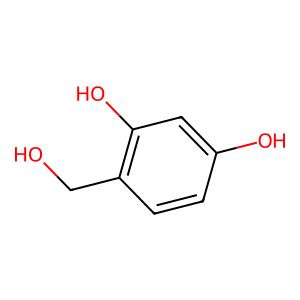

The predicted solubility using Random Forest Regressor is -1.415 log(mol/L)
The predicted solubility using Extra Trees Regressor is -1.264 log(mol/L)


{'Random Forest': -1.414857534638977, 'Extra Trees': -1.2637028608221634}

In [ ]:
# Cell 34: Example Usage of the Solubility Prediction Function

predict_sol('OCC1=C(O)C=C(O)C=C1')

In [ ]:
# Cell 35: Predicting Solubility for a List of SMILES Strings

# Define a function that predicts solubility for a list of SMILES strings
def predict_sol_list(smiles):

    # Validate the input collection
    if not isinstance(smiles, (list, tuple)):
        raise TypeError("smiles must be a list or tuple of SMILES strings.")

    if len(smiles) == 0:
        raise ValueError("The SMILES list is empty.")

    # Lists for descriptor calculation and cleaner visualization
    mols = []
    mols_for_image = []

    # Convert and validate every SMILES string
    for index, smile in enumerate(smiles):

        if not isinstance(smile, str) or not smile.strip():
            raise ValueError(
                f"SMILES at position {index} must be a non-empty string."
            )

        mol = Chem.MolFromSmiles(smile)

        if mol is None:
            raise ValueError(
                f"Could not parse SMILES at position {index}: {smile!r}"
            )

        # Keep a hydrogen-free copy for clearer molecular drawings
        mols_for_image.append(Chem.Mol(mol))

        # Add explicit hydrogens before descriptor calculation
        mol = Chem.AddHs(mol)

        # Generate a reproducible 3D conformer
        embed_status = AllChem.EmbedMolecule(
            mol,
            randomSeed=45
        )

        if embed_status != 0:
            raise ValueError(
                f"Could not generate a 3D conformer at position "
                f"{index}: {smile!r}"
            )

        mols.append(mol)

    # Store all molecule objects in a DataFrame
    df_mol = pd.DataFrame({
        'mol': mols
    })

    # Create the same Mordred descriptor calculator used during training
    calc = Calculator(
        descriptors,
        ignore_3D=False
    )

    # Calculate molecular descriptors
    desc = calc.pandas(df_mol['mol'])

    # Use the exact descriptors and ordering used by the final models
    required_features = X_train_final.columns.tolist()

    # Check that every required descriptor is present
    missing_features = [
        feature
        for feature in required_features
        if feature not in desc.columns
    ]

    if missing_features:
        raise ValueError(
            f"Required descriptors were not calculated: "
            f"{missing_features}"
        )

    # Select features in exactly the training order
    desc_8 = desc[required_features].copy()

    # Convert Mordred values to numeric
    desc_8 = desc_8.apply(
        pd.to_numeric,
        errors='coerce'
    )

    # Identify molecules with failed descriptor calculations
    invalid_rows = desc_8.isna().any(axis=1)

    if invalid_rows.any():
        invalid_details = {}

        for row_index in desc_8.index[invalid_rows]:
            invalid_details[smiles[row_index]] = (
                desc_8.columns[
                    desc_8.loc[row_index].isna()
                ].tolist()
            )

        raise ValueError(
            f"Could not calculate valid descriptor values for: "
            f"{invalid_details}"
        )

    # Standardize using the scaler fitted on the final training set
    X_new = pd.DataFrame(
        scaler_final.transform(desc_8),
        columns=required_features,
        index=desc_8.index
    )

    # Predict using the final trained models
    predict_rf = rf_final.predict(X_new)
    predict_et = et_final.predict(X_new)

    # Store predictions in a structured table
    prediction_results = pd.DataFrame({
        'SMILES': smiles,
        'Random Forest prediction': predict_rf,
        'Extra Trees prediction': predict_et
    })

    # Create labels for the molecular grid
    molecule_labels = [
        (
            f'SMILES: {smile}\n'
            f'RF: {rf_prediction:.3f}\n'
            f'ET: {et_prediction:.3f}'
        )
        for smile, rf_prediction, et_prediction in zip(
            smiles,
            predict_rf,
            predict_et
        )
    ]

    # Draw all molecules in one grid
    mol_grid = Draw.MolsToGridImage(
        mols_for_image,
        molsPerRow=3,
        subImgSize=(300, 250),
        legends=molecule_labels
    )

    # Display molecules and predictions
    display(mol_grid)
    display(prediction_results)

    # Return the table for later use
    return prediction_results

100%|██████████| 3/3 [00:00<00:00,  4.53it/s]


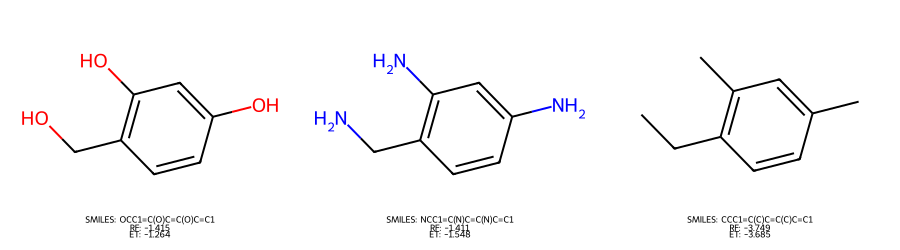

,SMILES,Random Forest prediction,Extra Trees prediction
0,OCC1=C(O)C=C(O)C=C1,-1.414858,-1.263703
1,NCC1=C(N)C=C(N)C=C1,-1.411474,-1.548354
2,CCC1=C(C)C=C(C)C=C1,-3.748598,-3.684897


,SMILES,Random Forest prediction,Extra Trees prediction
0,OCC1=C(O)C=C(O)C=C1,-1.414858,-1.263703
1,NCC1=C(N)C=C(N)C=C1,-1.411474,-1.548354
2,CCC1=C(C)C=C(C)C=C1,-3.748598,-3.684897


In [ ]:
# Cell 36: Example Usage of the Solubility Prediction Function for Multiple SMILES

smiles = ['OCC1=C(O)C=C(O)C=C1', 'NCC1=C(N)C=C(N)C=C1', 'CCC1=C(C)C=C(C)C=C1']
predict_sol_list(smiles)